# Causal Inference: Measuring the Unseen

Forecasting answers *"what will happen?"* Causal inference answers *"what is the effect of doing X on Y?"* Pearl's ladder splits the question into three rungs:

- **Association** $P(y \mid x)$: "What does seeing $X$ tell me about $Y$?" (standard forecasting)
- **Intervention** $P(y \mid do(x))$: "What if I do $X$?" (effect of an action)
- **Counterfactuals** $P(y_x \mid x', y')$: "What if I had done $X$?" (retrospective attribution)

In this notebook we tackle two complementary workflows:

1. **Causal discovery** with [Tigramite](https://github.com/jakobrunge/tigramite) — recovering the causal graph from observational time series.
2. **Intervention analysis** with [CausalImpact](https://github.com/dafiti/causalimpact) — quantifying the effect of a shock using a Bayesian structural time series (BSTS) synthetic control.
3. **Robustness** with [DoWhy](https://github.com/py-why/dowhy) — refuting a causal claim with placebo and random-common-cause tests.

## 1. Causal discovery with Tigramite

We simulate a coupled system in which a hidden **Market Index** drives both **Asset A** and **Volatility**. A naive correlation would flag Asset ↔ Volatility as a causal link. The PCMCI algorithm — a two-step procedure combining condition selection ($PC_1$) with Momentary Conditional Independence (MCI) tests — correctly identifies the common driver and removes the spurious edge.

In [1]:
import numpy as np
import pandas as pd
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr


def simulate_financial_system(n_steps: int = 1000) -> np.ndarray:
    """Simulate a system where:
    - Market Index (var 1) drives Asset A (var 0) and Volatility (var 2).
    - Asset A does NOT cause Volatility directly.
    """
    np.random.seed(42)
    data = np.random.randn(n_steps, 3)

    for t in range(2, n_steps):
        # Var 1: Market Index (driver) — strong trend
        data[t, 1] += 0.8 * data[t - 1, 1]
        # Var 0: Asset A (driven by Index)
        data[t, 0] += 0.4 * data[t - 1, 0] + 0.5 * data[t - 1, 1]
        # Var 2: Volatility (driven by Index with lag 2)
        data[t, 2] += 0.3 * data[t - 1, 2] + 0.6 * data[t - 2, 1]

    return data

In [2]:
# 1. Prepare data — Tigramite uses its own DataFrame wrapper
n_steps = 1000
data_array = simulate_financial_system(n_steps)
var_names = ["$X_0$ (Asset)", "$X_1$ (Index)", "$X_2$ (Vol)"]

dataframe = pp.DataFrame(
    data_array,
    datatime=np.arange(len(data_array)),
    var_names=var_names,
)

# 2. Run PCMCI with partial correlation (linear discovery)
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=ParCorr(significance="analytic"),
    verbosity=0,
)

results = pcmci.run_pcmci(tau_max=5, pc_alpha=0.01, alpha_level=0.01)

In [3]:
# 3. Analyze results — print significant lagged links
print("--- Significant Causal Links ---")
graph = results["graph"]
val_matrix = results["val_matrix"]

for j in range(3):  # targets
    for i in range(3):  # drivers
        for tau in range(6):
            if graph[i, j, tau] != "":
                strength = val_matrix[i, j, tau]
                print(
                    f"Link: {var_names[i]}(t-{tau}) -> {var_names[j]}(t) | "
                    f"Val: {strength:.3f}"
                )

--- Significant Causal Links ---
Link: $X_0$ (Asset)(t-1) -> $X_0$ (Asset)(t) | Val: 0.357
Link: $X_1$ (Index)(t-1) -> $X_0$ (Asset)(t) | Val: 0.445
Link: $X_1$ (Index)(t-1) -> $X_1$ (Index)(t) | Val: 0.633
Link: $X_1$ (Index)(t-1) -> $X_2$ (Vol)(t) | Val: -0.098
Link: $X_1$ (Index)(t-2) -> $X_2$ (Vol)(t) | Val: 0.552
Link: $X_2$ (Vol)(t-1) -> $X_2$ (Vol)(t) | Val: 0.313


**Interpretation.** Standard correlation would suggest a link between Asset ($X_0$) and Volatility ($X_2$) because they move together. PCMCI, by conditioning on the common driver ($X_1$), correctly identifies there is no direct link — preventing a spurious conclusion.

## 2. Intervention analysis with CausalImpact

Discovery finds structure. Stakeholders usually want numbers: *"How much revenue did the ad campaign generate?"* CausalImpact avoids the need for a strict control group by constructing a **synthetic control** with a Bayesian Structural Time Series model:

1. **Pre-intervention.** Train a BSTS model to predict the target $Y$ from unaffected covariates $X$.
2. **Counterfactual.** Project the fitted relationship into the post-intervention window to predict what $Y$ would have been without the event.
3. **Effect.** The difference between observed $Y$ and the counterfactual is the causal impact.

We simulate a *Volmageddon* scenario, modeled on the 2018 event where the VIX doubled overnight after short-volatility products collapsed. A synthetic global commodity index acts as a control covariate (assumed unaffected by the local policy shock).

In [4]:
from causalimpact import CausalImpact


def create_intervention_data() -> pd.DataFrame:
    dates = pd.date_range(start="2020-01-01", periods=365, freq="D")
    n = len(dates)

    # Control: global commodity index (unaffected by local policy)
    np.random.seed(123)
    X = np.cumsum(np.random.randn(n)) + 100

    # Target: VIX tracks the commodity index + noise
    y = 1.2 * X + np.random.randn(n) * 2

    # INTERVENTION: on day 250 a policy change causes a spike
    intervention_start = 250
    y[intervention_start:] += 20  # the "lift"

    return pd.DataFrame({"y": y, "X": X}, index=dates)


data = create_intervention_data()

pre_period = ["2020-01-01", "2020-09-06"]   # training
post_period = ["2020-09-07", "2020-12-30"]  # evaluation

ci = CausalImpact(data, pre_period, post_period, prior_level_sd=None)

/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/causalimpact/main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/causalimpact/main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: prior_level_sd, standardiz

/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [5]:
print("--- Causal Impact Summary ---")
print(ci.summary())

--- Causal Impact Summary ---
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    130.82             15044.34
Prediction (s.d.)         110.99 (0.31)      12764.1 (35.25)
95% CI                    [110.38, 111.58]   [12693.57, 12831.76]

Absolute effect (s.d.)    19.83 (0.31)       2280.24 (35.25)
95% CI                    [19.24, 20.44]     [2212.58, 2350.77]

Relative effect (s.d.)    17.86% (0.28%)     17.86% (0.28%)
95% CI                    [17.33%, 18.42%]   [17.33%, 18.42%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


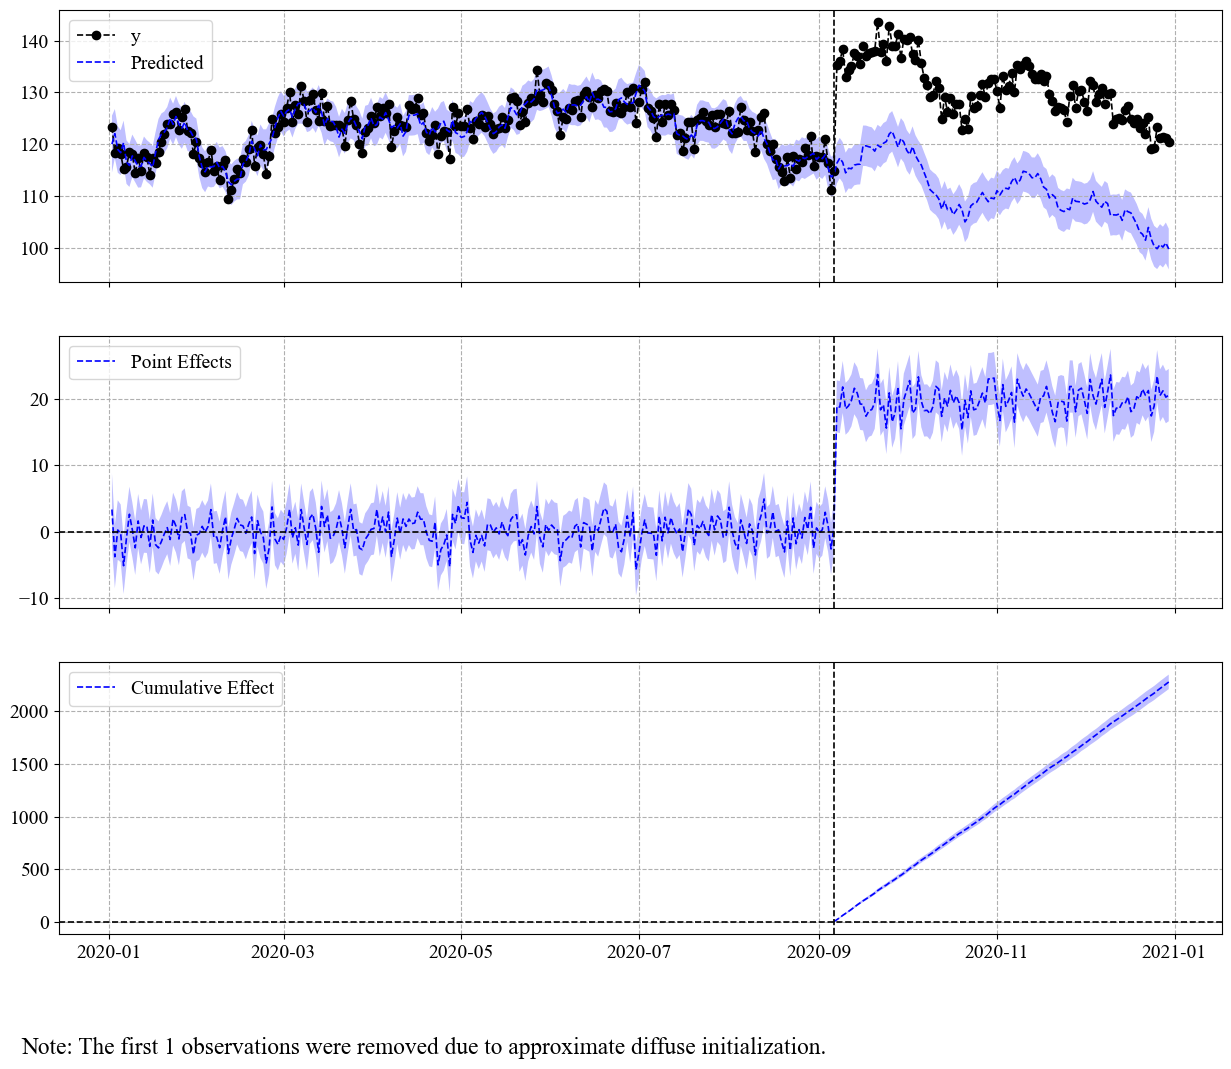

In [6]:
ci.plot()  # visualizes original vs. counterfactual

The output includes a **pointwise effect** (daily impact) and a **cumulative effect**. In marketing, the cumulative plot is critical: if a campaign causes a spike on Day 1 but a dip on Day 2 (cannibalization), only the cumulative curve reveals whether true incremental value was created.

## 3. Robustness checks with DoWhy

Discovery and intervention both rely on assumptions. DoWhy (by Microsoft) provides a four-step framework to make these assumptions explicit and testable:

1. **Model** — specify the causal graph (DAG).
2. **Identify** — check whether the effect is computable (backdoor criterion).
3. **Estimate** — calculate the effect under the chosen estimator.
4. **Refute** — stress-test the estimate with placebo and random-common-cause tests.

The refutation step is the critical one: if adding a random common cause or replacing the treatment with a placebo significantly changes the estimate, the causal claim is fragile.

In [7]:
from dowhy import CausalModel

# Simulate a marketing system with a confounder (Seasonality)
np.random.seed(0)
n = 500
seasonality = np.random.randn(n)
competitor = np.random.randn(n)
marketing = 0.5 * seasonality + np.random.randn(n)
sales = 2.0 * marketing + 0.8 * seasonality + 0.3 * competitor + np.random.randn(n)

df = pd.DataFrame(
    {
        "Marketing": marketing,
        "Sales": sales,
        "Seasonality": seasonality,
        "Competitor_Activity": competitor,
    }
)

In [8]:
# 1. Model: define the assumptions (DAG)
causal_graph = """digraph {
    Marketing -> Sales;
    Seasonality -> Marketing;
    Seasonality -> Sales;
    Competitor_Activity -> Sales;
}"""

model = CausalModel(
    data=df,
    treatment="Marketing",
    outcome="Sales",
    graph=causal_graph,
)

# 2. Identify: check if the effect is computable (backdoor criterion)
identified_estimand = model.identify_effect()

# 3. Estimate: calculate the effect
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)
print(f"Causal estimate: {estimate.value:.3f}  (ground truth ≈ 2.0)")

Causal estimate: 1.946  (ground truth ≈ 2.0)


/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


In [9]:
# 4. Refute: add a random common cause — the estimate should not change
refutation = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause",
)
print(refutation)

/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)
/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn

/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


...

/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)
/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn

/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)
/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn

/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)
/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn

Refute: Add a random common cause
Estimated effect:1.9455553307170736
New effect:1.9458866412972187
p value:0.8600000000000001



/Users/ben/anaconda3/envs/ml_timeseries/lib/python3.12/site-packages/dowhy/causal_estimator.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conditional_estimates = by_effect_mods.apply(estimate_effect_fn)


## Industry applications

- **Funds** use causal graphs (PCMCI) to detect regime shifts. If the causal parents of an asset change, that signals a structural break and prompts risk reduction.
- **Tech (Netflix)** uses surrogate metrics to estimate long-term effects (e.g., retention) from short-term signals (e.g., hours streamed), because six-month A/B tests are impractical.
- **Energy** operators use causal discovery to trace alarm storms back to a root cause node, reducing diagnosis time from hours to minutes.